# 03a Estimação Intervalar - Prática em Python

Este notebook traz três exemplos de simulação para reforçar os conceitos de estimativa pontual, intervalo de confiança, nível de confiança e margem de erro.

Material conceitual (teoria): `conceitos/03a_estimacao_intervalar_intro.md`



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
Z_95 = 1.96

## Exemplo 1: estimativa pontual vs estimativa intervalar

Vamos simular alturas de uma população com média real conhecida (`μ = 170`) e comparar:

- estimativa pontual (`x̄`)
- intervalo de confiança de 95% para a média (assumindo $\sigma$ conhecido)


In [ ]:
mu_real = 170
sigma_real = 10
n = 50

amostra = np.random.normal(loc=mu_real, scale=sigma_real, size=n)
x_bar = amostra.mean()
E = Z_95 * sigma_real / np.sqrt(n)
ic_inf, ic_sup = x_bar - E, x_bar + E

print(f"Estimativa pontual (x̄): {x_bar:.2f}")
print(f"IC 95% para μ: [{ic_inf:.2f}, {ic_sup:.2f}]")
print(f"μ real = {mu_real} está dentro do IC? {ic_inf <= mu_real <= ic_sup}")


In [ ]:
plt.figure(figsize=(8, 2.5))
plt.hlines(1, ic_inf, ic_sup, color='tab:blue', linewidth=3, label='IC 95%')
plt.plot(x_bar, 1, 'o', color='tab:orange', label='x̄')
plt.axvline(mu_real, color='tab:red', linestyle='--', label='μ real')
plt.yticks([])
plt.xlabel('Valor')
plt.title('Estimativa pontual vs intervalo de confiança')
plt.legend(loc='upper right')
plt.show()

## Exemplo 2: cobertura do nível de confiança (95%)

Vamos repetir o experimento várias vezes e medir em quantas amostras o IC 95% (com $\sigma$ conhecido) contém a média real `μ`.


In [ ]:
n_exp = 1000
n = 50
contidos = 0
intervalos = []

for _ in range(n_exp):
    amostra = np.random.normal(loc=mu_real, scale=sigma_real, size=n)
    x_bar = amostra.mean()
    E = Z_95 * sigma_real / np.sqrt(n)
    lo, hi = x_bar - E, x_bar + E
    intervalos.append((lo, hi))
    contidos += int(lo <= mu_real <= hi)

cobertura = contidos / n_exp
print(f"Cobertura observada: {cobertura:.3f} ({contidos}/{n_exp})")


In [ ]:
plt.figure(figsize=(5, 3))
plt.bar(['Contém μ', 'Não contém μ'], [contidos, n_exp - contidos], color=['tab:green', 'tab:red'])
plt.title('Cobertura empírica dos ICs de 95%')
plt.ylabel('Quantidade de intervalos')
plt.show()

## Exemplo 3: margem de erro em função de `n`

Vamos comparar a margem de erro média (com $\sigma$ conhecido) para diferentes tamanhos amostrais.


In [ ]:
tamanhos = [20, 50, 100, 300, 1000]
repeticoes = 500
margens_medias = []

for n in tamanhos:
    margens = []
    for _ in range(repeticoes):
        amostra = np.random.normal(loc=mu_real, scale=sigma_real, size=n)
        E = Z_95 * sigma_real / np.sqrt(n)
        margens.append(E)
    margens_medias.append(np.mean(margens))

for n, e in zip(tamanhos, margens_medias):
    print(f"n={n:4d} -> margem de erro média ≈ {e:.3f}")


In [ ]:
plt.figure(figsize=(6, 3.5))
plt.plot(tamanhos, margens_medias, marker='o')
plt.xlabel('Tamanho da amostra (n)')
plt.ylabel('Margem de erro média (E)')
plt.title('Margem de erro diminui com o aumento de n')
plt.grid(alpha=0.3)
plt.show()

## Exercícios sugeridos

1. Troque o nível de confiança de 95% para 90% e 99% e compare a largura dos intervalos.
2. Repita os experimentos com diferentes tamanhos amostrais (`n = 20, 50, 200, 1000`) e descreva o impacto na margem de erro.
3. Substitua a população normal por uma distribuição assimétrica (por exemplo, lognormal) e observe o comportamento da cobertura.
4. No experimento de cobertura, aumente o número de repetições e compare a estabilidade da estimativa de cobertura.
5. Faça uma simulação com variância populacional maior e analise como isso afeta os intervalos de confiança.


---

## Parte 2: Estimadores (viés e variância)

Nesta parte, incorporamos as simulações sobre viés, variância e EQM, em continuidade ao conteúdo de estimação intervalar.



## Objetivo da prática

Visualizar como diferentes combinações de viés e variância afetam o comportamento de um estimador.


## Conceitos que serão observados no código

- estimador não-viesado vs viesado
- alta vs baixa variância
- impacto visual da combinação viés-variância


## Simulação 1: diagrama viés × variância

O gráfico a seguir mostra quatro cenários clássicos de estimadores em relação ao valor verdadeiro.


Interprete os quadrantes como:

- baixo viés, alta variância;
- baixo viés, baixa variância (ideal);
- alto viés, alta variância;
- alto viés, baixa variância.


## Simulação 2: estimativa da variância populacional

Agora vamos comparar dois estimadores da variância:

1. estimador com divisor `n` (viesado);
2. estimador com divisor `n-1` (correção de Bessel, não-viesado).


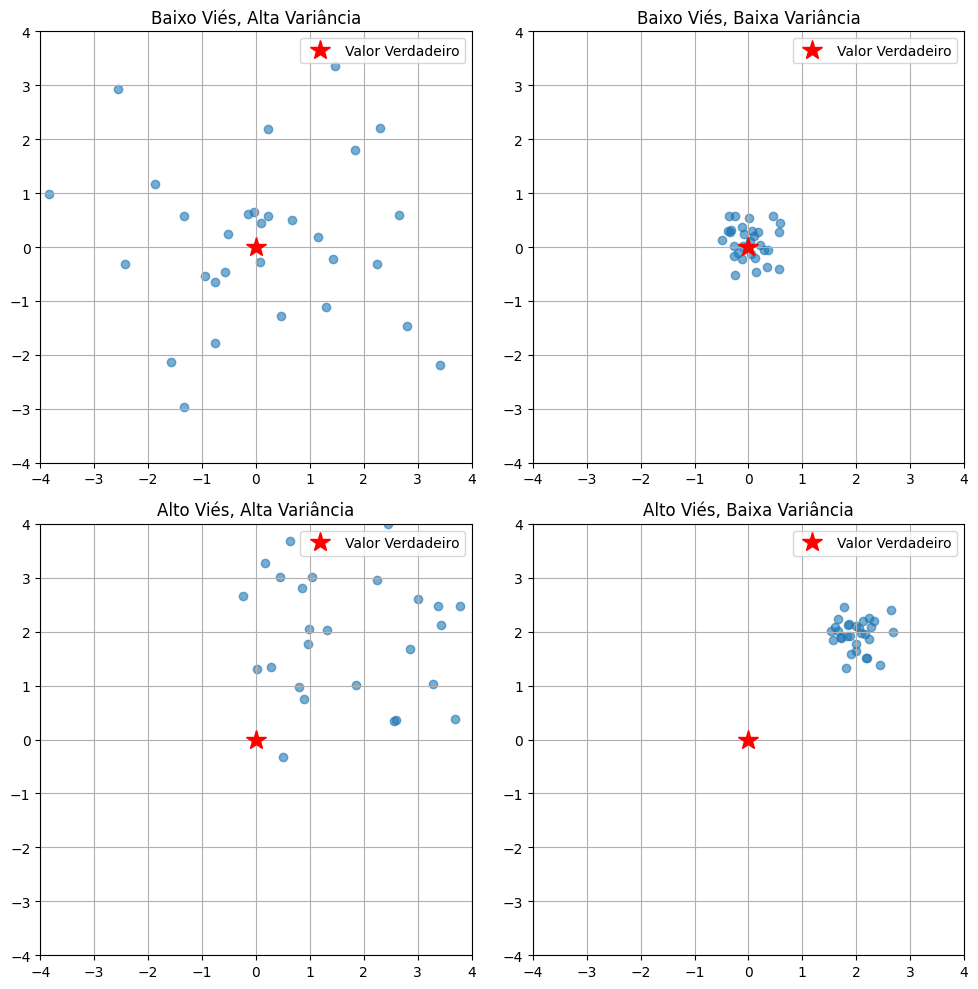

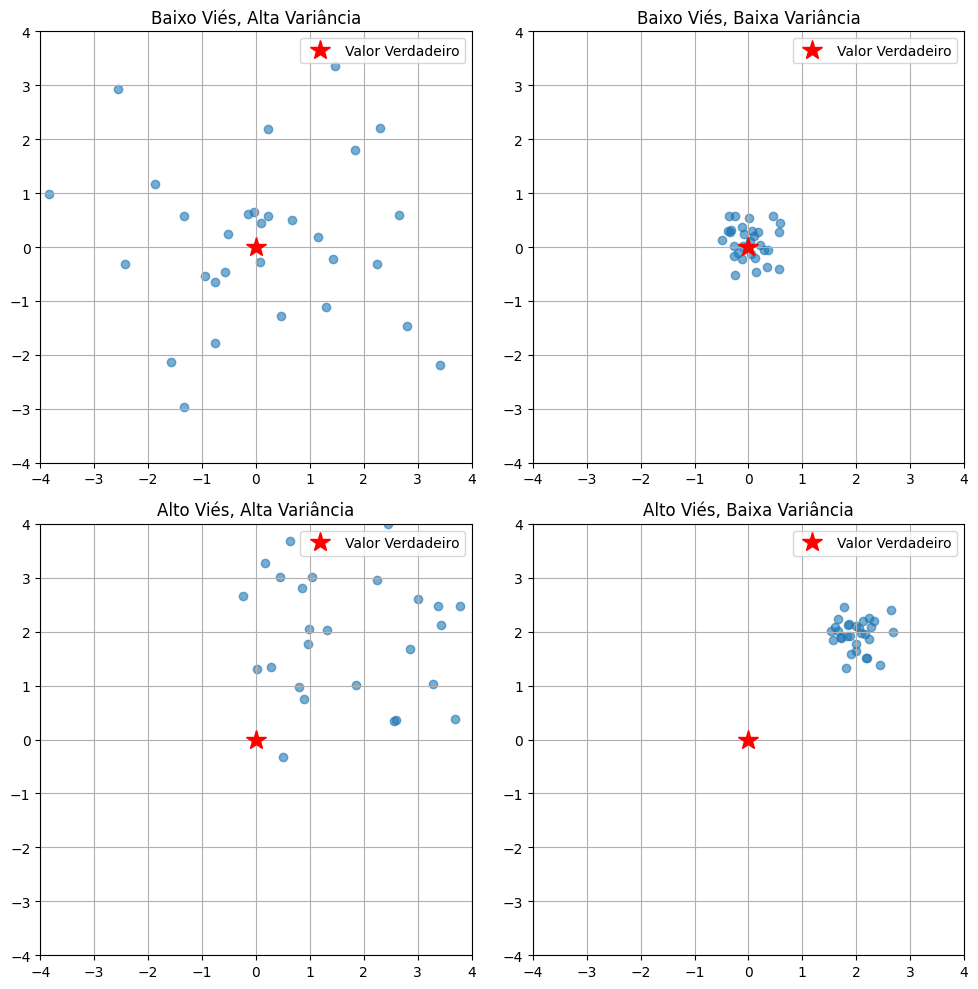

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Função para desenhar os alvos
def plot_bias_variance_diagram():
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    titles = [
        "Baixo Viés, Alta Variância",
        "Baixo Viés, Baixa Variância",
        "Alto Viés, Alta Variância",
        "Alto Viés, Baixa Variância"
    ]
    
    # Centro real do alvo
    true_value = np.array([0, 0])
    
    # Padrões de dispersão das estimativas
    np.random.seed(0)
    scatter_patterns = [
        np.random.normal(loc=true_value, scale=1.5, size=(30, 2)),  # alta variância
        np.random.normal(loc=true_value, scale=0.3, size=(30, 2)),  # baixa variância
        np.random.normal(loc=[2, 2], scale=1.5, size=(30, 2)),      # alto viés, alta variância
        np.random.normal(loc=[2, 2], scale=0.3, size=(30, 2))       # alto viés, baixa variância
    ]
    
    for ax, title, pattern in zip(axes.flat, titles, scatter_patterns):
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_aspect('equal')
        ax.set_title(title)
        ax.plot(0, 0, 'r*', markersize=15, label='Valor Verdadeiro')
        ax.scatter(pattern[:, 0], pattern[:, 1], alpha=0.6)
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    return fig

# Gerar o gráfico
plot_bias_variance_diagram()

A ideia é simular amostras i.i.d. de uma superpopulação com variância verdadeira conhecida e comparar o comportamento médio dos estimadores ao longo das repetições.


Primeiro, definimos a distribuição geradora e o valor verdadeiro de referência para a variância.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Superpopulação: Normal(0, 3^2)
mu_pop = 0.0
sigma_pop = 3.0
sigma2_true = sigma_pop ** 2

n = 30
num_samples = 1000

print(f'Variância verdadeira (σ²): {sigma2_true:.2f}')


Variância populacional: 8.161900000000001


Em seguida, calculamos as variâncias amostrais com divisor `n` e `n-1` em cada repetição e acompanhamos suas médias acumuladas.


In [ ]:
# Gera num_samples amostras i.i.d., cada uma com tamanho n
samples = np.random.normal(loc=mu_pop, scale=sigma_pop, size=(num_samples, n))

# Estimativas de variância em cada amostra
var_biased = samples.var(axis=1, ddof=0)   # divisor n
var_unbiased = samples.var(axis=1, ddof=1) # divisor n-1

print(f'Média das estimativas (ddof=0): {var_biased.mean():.3f}')
print(f'Média das estimativas (ddof=1): {var_unbiased.mean():.3f}')

# Séries de médias acumuladas (convergência)
running_biased = pd.Series(var_biased).expanding().mean()
running_unbiased = pd.Series(var_unbiased).expanding().mean()

df = pd.DataFrame({
    'biased var estimate (divide by n)': running_biased,
    'unbiased var estimate (divide by n - 1)': running_unbiased,
    'true variance': sigma2_true
})


In [ ]:
display(df.tail())

ax = df.plot(figsize=(8,4), ylim=(sigma2_true-1.5, sigma2_true+1.5))
ax.set_title('Convergência média: estimadores da variância')
ax.set_xlabel('Número de amostras acumuladas')
ax.set_ylabel('Valor estimado')
ax.grid(alpha=0.3)
plt.show()
